In [1]:
# Imports and device setup
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import os

from torchvision import datasets, transforms

try:
    import timm
except ImportError as e:
    raise ImportError('timm is required for this notebook. Install with `pip install timm`.') from e

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

c:\Anaconda\envs\clone_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Data loading: reuse existing YOLO face splits in data_yolo_faces
DATA_ROOT = Path('../data_yolo_faces')
train_dir = DATA_ROOT / 'train'
val_dir = DATA_ROOT / 'val'
test_dir = DATA_ROOT / 'test'

print('CWD        :', Path.cwd())
print('Train path :', train_dir.resolve())
print('Train exists:', train_dir.exists())

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transform)
val_dataset = datasets.ImageFolder(root=str(val_dir), transform=eval_transform)
test_dataset = datasets.ImageFolder(root=str(test_dir), transform=eval_transform)

print('Classes:', train_dataset.classes)
print('Train images:', len(train_dataset))
print('Val images  :', len(val_dataset))
print('Test images :', len(test_dataset))

batch_size = 32  # closer to FF++ paper, safe for Xception on 12GB VRAM
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)

CWD        : c:\Users\ASUS\Documents\Deep Learning\notebooks
Train path : C:\Users\ASUS\Documents\Deep Learning\data_yolo_faces\train
Train exists: True
Classes: ['FAKE', 'REAL']
Train images: 97156
Val images  : 20759
Test images : 20784


(3037, 649, 650)

In [3]:
# Build Xception model and weighted cross-entropy criterion
def create_xception(num_classes: int = 2, pretrained: bool = True) -> nn.Module:
    model = timm.create_model('xception', pretrained=pretrained, num_classes=num_classes)
    return model

def get_class_counts(dataset):
    counts = [0] * len(dataset.classes)
    for _, label in dataset:
        counts[label] += 1
    return counts

def build_weighted_ce_criterion(train_dataset, device):
    counts = np.array(get_class_counts(train_dataset), dtype=np.float32)
    total = counts.sum()
    # inverse-frequency weights (higher weight for minority class)
    weights = total / counts
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    def criterion(outputs, targets):
        return F.cross_entropy(outputs, targets, weight=weights)

    return criterion, weights

model = create_xception(num_classes=2, pretrained=True).to(device)

criterion, class_weights = build_weighted_ce_criterion(train_dataset, device)
print('Class counts   :', get_class_counts(train_dataset))
print('Class weights  :', class_weights.detach().cpu().numpy())

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

total_params = sum(p.numel() for p in model.parameters())
print('Total parameters (Xception):', total_params)
model

c:\Anaconda\envs\clone_gpu\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Class counts   : [83313, 13843]
Class weights  : [1.1661565 7.0184207]
Total parameters (Xception): 20811050


Xception(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU(inplace=True)
  (block1): Block(
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (rep): Sequential(
      (0): SeparableConv2d(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): SeparableConv2d(
        (conv1): Conv

In [4]:
# Training and validation loops with early stopping
import time
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Training', unit='batch'):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Validation', unit='batch'):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

num_epochs = 15  # fewer epochs, but larger model than ResNet18
patience = 5
no_improve_count = 0

best_val_acc = 0.0
best_state_dict = None

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    start_time = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - start_time

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(
        f'Epoch {epoch+1}/{num_epochs} | ' 
        f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, ' 
        f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, ' 
        f'time={elapsed:.1f}s'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()
        no_improve_count = 0
        print(f'--> New Best Model! (Val Acc: {best_val_acc:.4f})')
    else:
        no_improve_count += 1
        print(f'--> No improvement for {no_improve_count}/{patience} epochs.')

    if no_improve_count >= patience:
        print('Early Stopping triggered! Stopping training.')
        break

print('Best val acc:', best_val_acc)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    torch.save(model.state_dict(), 'best_xception_ffpp_yolo_faces.pth')
    print('Saved best model to best_xception_ffpp_yolo_faces.pth')

Validation: 100%|██████████| 649/649 [01:14<00:00,  8.72batch/s]


Epoch 1/15 | train_loss=0.3009, train_acc=0.8671, val_loss=0.2491, val_acc=0.8952, time=2222.8s
--> New Best Model! (Val Acc: 0.8952)


Validation: 100%|██████████| 649/649 [00:57<00:00, 11.30batch/s]


Epoch 2/15 | train_loss=0.1361, train_acc=0.9430, val_loss=0.2367, val_acc=0.9016, time=1041.5s
--> New Best Model! (Val Acc: 0.9016)


Validation: 100%|██████████| 649/649 [00:54<00:00, 11.89batch/s]


...

Epoch 13/15 | train_loss=0.0257, train_acc=0.9878, val_loss=0.3459, val_acc=0.9207, time=518.5s
--> No improvement for 2/5 epochs.


Validation: 100%|██████████| 649/649 [00:58<00:00, 11.09batch/s]


Epoch 14/15 | train_loss=0.0248, train_acc=0.9886, val_loss=0.3017, val_acc=0.9226, time=499.4s
--> New Best Model! (Val Acc: 0.9226)


Validation: 100%|██████████| 649/649 [01:10<00:00,  9.25batch/s]

Epoch 15/15 | train_loss=0.0248, train_acc=0.9882, val_loss=0.3158, val_acc=0.9226, time=514.1s
--> No improvement for 1/5 epochs.
Best val acc: 0.9226359651235608
Saved best model to best_xception_ffpp_yolo_faces.pth


In [5]:
# Test evaluation: accuracy, confusion matrix, classification report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def evaluate_simple(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += inputs.size(0)
    return correct / total if total > 0 else 0.0

test_acc = evaluate_simple(model, test_loader, device)
print('Test accuracy (Xception, YOLO faces):', test_acc)

@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_preds, all_labels

y_pred, y_true = get_predictions_and_labels(model, test_loader, device)

cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix (rows=true, cols=pred):')
print(cm)

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=train_dataset.classes, digits=4))

Test accuracy (Xception, YOLO faces): 0.9128175519630485
Confusion Matrix (rows=true, cols=pred):
[[16799  1025]
 [  787  2173]]
Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9552    0.9425    0.9488     17824
        REAL     0.6795    0.7341    0.7057      2960

    accuracy                         0.9128     20784
   macro avg     0.8174    0.8383    0.8273     20784
weighted avg     0.9160    0.9128    0.9142     20784



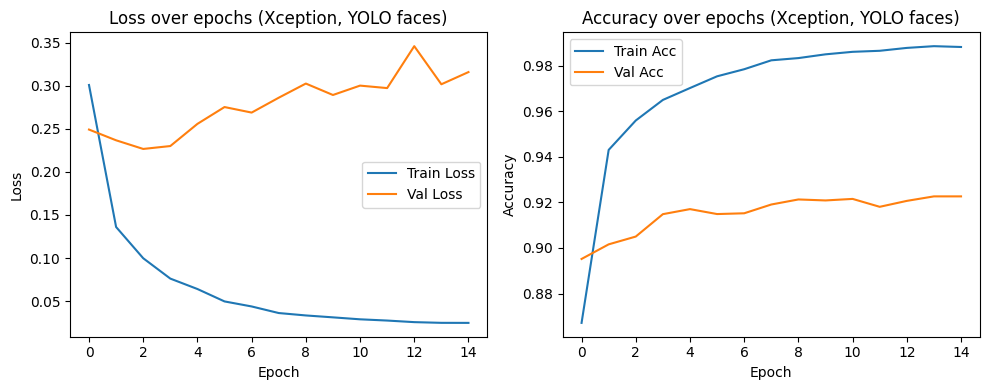

: 

In [ ]:
# Optional: plot training curves
if history['train_loss']:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over epochs (Xception, YOLO faces)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over epochs (Xception, YOLO faces)')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history to plot yet.')